In [1]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4

In [2]:
import requests
from bs4 import BeautifulSoup
from datetime import date
import pandas as pd

# Empezamos con Argentina 1986
url = "https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Argentina_en_la_Copa_Mundial_de_1986"

response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

print(f"Status: {response.status_code}")
print(f"Título de la página: {soup.title.text}")

Status: 403


AttributeError: 'NoneType' object has no attribute 'text'

In [3]:
# Agregamos headers para simular un navegador
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

url = "https://es.wikipedia.org/wiki/Selección_de_fútbol_de_Argentina_en_la_Copa_Mundial_de_1986"

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

print(f"Status: {response.status_code}")
print(f"Título de la página: {soup.title.text}")

Status: 404
Título de la página: Selección de fútbol de Argentina en la Copa Mundial de 1986 - Wikipedia, la enciclopedia libre


In [4]:
url = "https://en.wikipedia.org/wiki/Argentina_at_the_1986_FIFA_World_Cup"

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

print(f"Status: {response.status_code}")
print(f"Título: {soup.title.text}")

# Veamos todas las tablas disponibles en la página
tablas = soup.find_all('table', {'class': 'wikitable'})
print(f"\nTablas encontradas: {len(tablas)}")

Status: 404
Título: Argentina at the 1986 FIFA World Cup - Wikipedia

Tablas encontradas: 0


In [5]:
# Intentamos con la URL más estándar de Wikipedia
url = "https://en.wikipedia.org/wiki/1986_FIFA_World_Cup_squads"

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

print(f"Status: {response.status_code}")
print(f"Título: {soup.title.text}")

tablas = soup.find_all('table', {'class': 'wikitable'})
print(f"Tablas encontradas: {len(tablas)}")

Status: 200
Título: 1986 FIFA World Cup squads - Wikipedia
Tablas encontradas: 25


In [6]:
# Buscamos los encabezados para encontrar Argentina
for i, tabla in enumerate(tablas):
    encabezado = tabla.find_previous(['h2', 'h3'])
    if encabezado and 'Argentina' in encabezado.text:
        print(f"Tabla {i}: {encabezado.text.strip()}")
        print(tabla.prettify()[:500])
        print("---")
        break

Tabla 0: Argentina
<table class="sortable wikitable plainrowheaders" style="font-size:100%; width:98%">
 <tbody>
  <tr>
   <th scope="col" style="width:5%">
    No.
   </th>
   <th scope="col" style="width:5%">
    Pos.
   </th>
   <th scope="col" style="width:30%">
    Player
   </th>
   <th scope="col" style="width:20%">
    Date of birth (age)
   </th>
   <th scope="col" style="width:5%">
    Caps
   </th>
   <th scope="col">
    Club
   </th>
  </tr>
  <tr class="nat-fs-player">
   <td>
    1
   </td>
   <td>

---


In [7]:
from datetime import date

def calcular_edad(fecha_str, fecha_mundial):
    try:
        # Wikipedia formato: (1966-03-15)
        fecha_str = fecha_str.strip()
        # Extraemos solo la fecha entre paréntesis
        import re
        match = re.search(r'\((\d{4}-\d{2}-\d{2})\)', fecha_str)
        if match:
            partes = match.group(1).split('-')
            nacimiento = date(int(partes[0]), int(partes[1]), int(partes[2]))
            delta = (fecha_mundial - nacimiento).days / 365.25
            return round(delta, 1)
    except:
        return None

# Fecha de inicio México 1986
fecha_mundial = date(1986, 5, 31)

# Extraemos datos de Argentina
tabla_arg = tablas[0]
jugadores = []

for fila in tabla_arg.find_all('tr', class_='nat-fs-player'):
    celdas = fila.find_all(['td', 'th'])
    if len(celdas) >= 4:
        posicion = celdas[1].text.strip()
        nombre = celdas[2].text.strip()
        fecha_text = celdas[3].text.strip()
        edad = calcular_edad(fecha_text, fecha_mundial)
        jugadores.append({
            'Jugador': nombre,
            'Posicion': posicion,
            'Edad': edad
        })

df_arg = pd.DataFrame(jugadores)
print(df_arg)

                     Jugador Posicion  Edad
0             Sergio Almirón      4FW  27.5
1             Sergio Batista      3MF  23.6
2            Ricardo Bochini      3MF  32.3
3             Claudio Borghi      3MF  21.7
4            José Luis Brown      2DF  29.6
5          Daniel Passarella      2DF  33.0
6           Jorge Burruchaga      3MF  23.6
7             Néstor Clausen      2DF  23.7
8         José Luis Cuciuffo      2DF  25.3
9   Diego Maradona (captain)      3MF  25.6
10             Jorge Valdano      4FW  30.7
11            Héctor Enrique      3MF  24.1
12               Oscar Garré      2DF  29.5
13            Ricardo Giusti      3MF  29.5
14                Luis Islas      1GK  20.4
15       Julio Olarticoechea      2DF  27.6
16            Pedro Pasculli      4FW  26.0
17              Nery Pumpido      1GK  28.8
18             Oscar Ruggeri      2DF  24.3
19              Carlos Tapia      3MF  23.8
20         Marcelo Trobbiani      3MF  31.3
21             Héctor Zelada    

In [8]:
# Mapeamos los códigos de Wikipedia a nombres claros
mapa_posiciones = {
    'GK': 'Portero',
    'DF': 'Defensa',
    'MF': 'Mediocampista',
    'FW': 'Delantero'
}

# Limpiamos la columna posición
df_arg['Pos_limpia'] = df_arg['Posicion'].str.extract(r'(\d)(\w+)')[1].map(mapa_posiciones)

# Promedio de edad por posición
promedio_pos = df_arg.groupby('Pos_limpia')['Edad'].mean().round(2)

print("Argentina 1986 — Edad promedio por posición:")
print(promedio_pos)

Argentina 1986 — Edad promedio por posición:
Pos_limpia
Defensa          27.57
Delantero        28.07
Mediocampista    26.17
Portero          26.10
Name: Edad, dtype: float64


In [9]:
mundiales = [
    {"año": 1986, "campeon": "Argentina", "fecha": date(1986, 5, 31), "url": "https://en.wikipedia.org/wiki/1986_FIFA_World_Cup_squads"},
    {"año": 1990, "campeon": "Alemania", "fecha": date(1990, 6, 8), "url": "https://en.wikipedia.org/wiki/1990_FIFA_World_Cup_squads"},
    {"año": 1994, "campeon": "Brasil", "fecha": date(1994, 6, 17), "url": "https://en.wikipedia.org/wiki/1994_FIFA_World_Cup_squads"},
    {"año": 1998, "campeon": "Francia", "fecha": date(1998, 6, 10), "url": "https://en.wikipedia.org/wiki/1998_FIFA_World_Cup_squads"},
    {"año": 2002, "campeon": "Brasil", "fecha": date(2002, 5, 31), "url": "https://en.wikipedia.org/wiki/2002_FIFA_World_Cup_squads"},
    {"año": 2006, "campeon": "Italia", "fecha": date(2006, 6, 9), "url": "https://en.wikipedia.org/wiki/2006_FIFA_World_Cup_squads"},
    {"año": 2010, "campeon": "España", "fecha": date(2010, 6, 11), "url": "https://en.wikipedia.org/wiki/2010_FIFA_World_Cup_squads"},
    {"año": 2014, "campeon": "Alemania", "fecha": date(2014, 6, 12), "url": "https://en.wikipedia.org/wiki/2014_FIFA_World_Cup_squads"},
    {"año": 2018, "campeon": "Francia", "fecha": date(2018, 6, 14), "url": "https://en.wikipedia.org/wiki/2018_FIFA_World_Cup_squads"},
    {"año": 2022, "campeon": "Argentina", "fecha": date(2022, 11, 20), "url": "https://en.wikipedia.org/wiki/2022_FIFA_World_Cup_squads"},
]

print(f"Mundiales configurados: {len(mundiales)}")

Mundiales configurados: 10


In [10]:
import time

resultados = []

for mundial in mundiales:
    print(f"Scraping {mundial['campeon']} {mundial['año']}...")
    
    response = requests.get(mundial['url'], headers=headers)
    soup = BeautifulSoup(response.content, 'html.parser')
    tablas = soup.find_all('table', {'class': 'wikitable'})
    
    # Encontramos la tabla del campeón
    tabla_campeon = None
    for tabla in tablas:
        encabezado = tabla.find_previous(['h2', 'h3'])
        if encabezado and mundial['campeon'] in encabezado.text:
            tabla_campeon = tabla
            break
    
    if tabla_campeon is None:
        print(f"  ⚠️ No encontrada: {mundial['campeon']}")
        continue
    
    # Extraemos jugadores
    for fila in tabla_campeon.find_all('tr', class_='nat-fs-player'):
        celdas = fila.find_all(['td', 'th'])
        if len(celdas) >= 4:
            posicion = celdas[1].text.strip()
            fecha_text = celdas[3].text.strip()
            edad = calcular_edad(fecha_text, mundial['fecha'])
            pos_code = posicion.strip()
            pos_limpia = None
            for key in mapa_posiciones:
                if key in pos_code:
                    pos_limpia = mapa_posiciones[key]
                    break
            if edad and pos_limpia:
                resultados.append({
                    'Mundial': mundial['año'],
                    'Campeon': mundial['campeon'],
                    'Posicion': pos_limpia,
                    'Edad': edad
                })
    
    time.sleep(1)  # Pausa para no saturar Wikipedia

print(f"\n✅ Total jugadores extraídos: {len(resultados)}")

Scraping Argentina 1986...
Scraping Alemania 1990...
  ⚠️ No encontrada: Alemania
Scraping Brasil 1994...
  ⚠️ No encontrada: Brasil
Scraping Francia 1998...
  ⚠️ No encontrada: Francia
Scraping Brasil 2002...
  ⚠️ No encontrada: Brasil
Scraping Italia 2006...
  ⚠️ No encontrada: Italia
Scraping España 2010...
  ⚠️ No encontrada: España
Scraping Alemania 2014...
  ⚠️ No encontrada: Alemania
Scraping Francia 2018...
  ⚠️ No encontrada: Francia
Scraping Argentina 2022...

✅ Total jugadores extraídos: 48


In [11]:
mundiales = [
    {"año": 1986, "campeon": "Argentina", "fecha": date(1986, 5, 31), "url": "https://en.wikipedia.org/wiki/1986_FIFA_World_Cup_squads"},
    {"año": 1990, "campeon": "West Germany", "fecha": date(1990, 6, 8), "url": "https://en.wikipedia.org/wiki/1990_FIFA_World_Cup_squads"},
    {"año": 1994, "campeon": "Brazil", "fecha": date(1994, 6, 17), "url": "https://en.wikipedia.org/wiki/1994_FIFA_World_Cup_squads"},
    {"año": 1998, "campeon": "France", "fecha": date(1998, 6, 10), "url": "https://en.wikipedia.org/wiki/1998_FIFA_World_Cup_squads"},
    {"año": 2002, "campeon": "Brazil", "fecha": date(2002, 5, 31), "url": "https://en.wikipedia.org/wiki/2002_FIFA_World_Cup_squads"},
    {"año": 2006, "campeon": "Italy", "fecha": date(2006, 6, 9), "url": "https://en.wikipedia.org/wiki/2006_FIFA_World_Cup_squads"},
    {"año": 2010, "campeon": "Spain", "fecha": date(2010, 6, 11), "url": "https://en.wikipedia.org/wiki/2010_FIFA_World_Cup_squads"},
    {"año": 2014, "campeon": "Germany", "fecha": date(2014, 6, 12), "url": "https://en.wikipedia.org/wiki/2014_FIFA_World_Cup_squads"},
    {"año": 2018, "campeon": "France", "fecha": date(2018, 6, 14), "url": "https://en.wikipedia.org/wiki/2018_FIFA_World_Cup_squads"},
    {"año": 2022, "campeon": "Argentina", "fecha": date(2022, 11, 20), "url": "https://en.wikipedia.org/wiki/2022_FIFA_World_Cup_squads"},
]

print("Mundiales actualizados ✅")

Mundiales actualizados ✅


In [12]:
import time

resultados = []

for mundial in mundiales:
    print(f"Scraping {mundial['campeon']} {mundial['año']}...")
    
    response = requests.get(mundial['url'], headers=headers)
    soup = BeautifulSoup(response.content, 'html.parser')
    tablas = soup.find_all('table', {'class': 'wikitable'})
    
    # Encontramos la tabla del campeón
    tabla_campeon = None
    for tabla in tablas:
        encabezado = tabla.find_previous(['h2', 'h3'])
        if encabezado and mundial['campeon'] in encabezado.text:
            tabla_campeon = tabla
            break
    
    if tabla_campeon is None:
        print(f"  ⚠️ No encontrada: {mundial['campeon']}")
        continue
    
    # Extraemos jugadores
    for fila in tabla_campeon.find_all('tr', class_='nat-fs-player'):
        celdas = fila.find_all(['td', 'th'])
        if len(celdas) >= 4:
            posicion = celdas[1].text.strip()
            fecha_text = celdas[3].text.strip()
            edad = calcular_edad(fecha_text, mundial['fecha'])
            pos_code = posicion.strip()
            pos_limpia = None
            for key in mapa_posiciones:
                if key in pos_code:
                    pos_limpia = mapa_posiciones[key]
                    break
            if edad and pos_limpia:
                resultados.append({
                    'Mundial': mundial['año'],
                    'Campeon': mundial['campeon'],
                    'Posicion': pos_limpia,
                    'Edad': edad
                })
    
    time.sleep(1)  # Pausa para no saturar Wikipedia

print(f"\n✅ Total jugadores extraídos: {len(resultados)}")

Scraping Argentina 1986...
Scraping West Germany 1990...
Scraping Brazil 1994...
Scraping France 1998...
Scraping Brazil 2002...
Scraping Italy 2006...
Scraping Spain 2010...
Scraping Germany 2014...
Scraping France 2018...
Scraping Argentina 2022...

✅ Total jugadores extraídos: 229


In [13]:
df_jugadores = pd.DataFrame(resultados)

# Promedio de edad por mundial, campeon y posicion
df_posiciones = df_jugadores.groupby(
    ['Mundial', 'Campeon', 'Posicion']
)['Edad'].mean().round(2).reset_index()

df_posiciones.columns = ['Mundial', 'Campeon', 'Posicion', 'Edad_Promedio']

print(df_posiciones)

    Mundial       Campeon       Posicion  Edad_Promedio
0      1986     Argentina        Defensa          27.57
1      1986     Argentina      Delantero          28.07
2      1986     Argentina  Mediocampista          26.17
3      1986     Argentina        Portero          26.10
4      1990  West Germany        Defensa          28.65
5      1990  West Germany      Delantero          28.17
6      1990  West Germany  Mediocampista          27.06
7      1990  West Germany        Portero          26.03
8      1994        Brazil        Defensa          28.30
9      1994        Brazil      Delantero          25.88
10     1994        Brazil  Mediocampista          27.68
11     1994        Brazil        Portero          30.97
12     1998        France        Defensa          28.72
13     1998        France      Delantero          23.88
14     1998        France  Mediocampista          26.64
15     1998        France        Portero          31.27
16     2002        Brazil        Defensa        

In [14]:
df_posiciones.to_csv('edad_por_posicion.csv', index=False)
print("✅ edad_por_posicion.csv exportado")
print(f"\nRegistros totales: {len(df_posiciones)}")
print("\nVista previa:")
print(df_posiciones.head(8))

✅ edad_por_posicion.csv exportado

Registros totales: 40

Vista previa:
   Mundial       Campeon       Posicion  Edad_Promedio
0     1986     Argentina        Defensa          27.57
1     1986     Argentina      Delantero          28.07
2     1986     Argentina  Mediocampista          26.17
3     1986     Argentina        Portero          26.10
4     1990  West Germany        Defensa          28.65
5     1990  West Germany      Delantero          28.17
6     1990  West Germany  Mediocampista          27.06
7     1990  West Germany        Portero          26.03


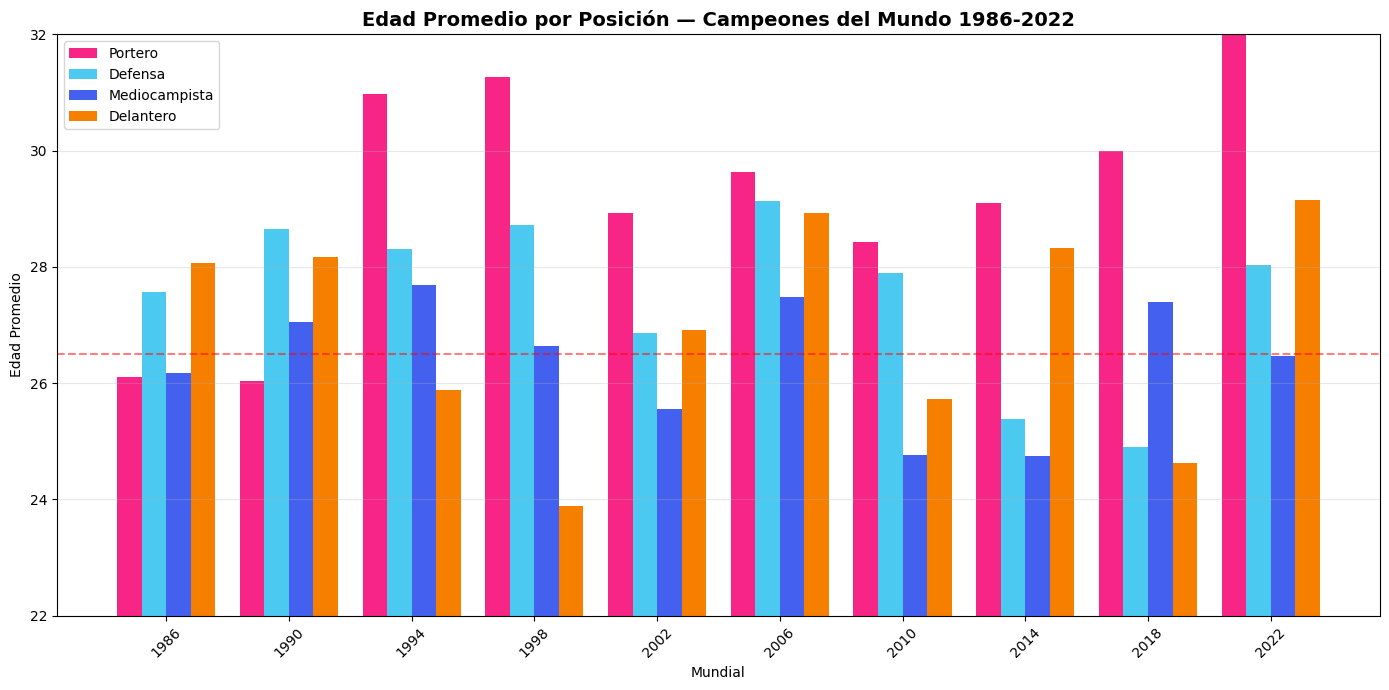

In [19]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(14, 7))

posiciones = ['Portero', 'Defensa', 'Mediocampista', 'Delantero']
colores = ['#f72585', '#4cc9f0', '#4361ee', '#f77f00']
mundiales_labels = df_posiciones['Mundial'].unique()

x = np.arange(len(mundiales_labels))
ancho = 0.2

for i, pos in enumerate(posiciones):
    datos_pos = df_posiciones[df_posiciones['Posicion'] == pos]
    datos_pos = datos_pos.set_index('Mundial').reindex(mundiales_labels)
    ax.bar(x + i * ancho, datos_pos['Edad_Promedio'], 
           ancho, label=pos, color=colores[i])

ax.set_title('Edad Promedio por Posición — Campeones del Mundo 1986-2022', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mundial')
ax.set_ylabel('Edad Promedio')
ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(mundiales_labels, rotation=45)
ax.legend()
ax.set_ylim(22, 32)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=26.5, color='red', linestyle='--', alpha=0.5, label='Ref. 26.5')

plt.tight_layout()
plt.show()

In [20]:
url = "https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_squads"

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

print(f"Status: {response.status_code}")
print(f"Título: {soup.title.text}")

tablas = soup.find_all('table', {'class': 'wikitable'})
print(f"Tablas encontradas: {len(tablas)}")

Status: 200
Título: 2026 FIFA World Cup squads - Wikipedia
Tablas encontradas: 53


In [21]:
# Veamos los encabezados de todas las tablas
equipos_disponibles = []

for i, tabla in enumerate(tablas):
    encabezado = tabla.find_previous(['h2', 'h3'])
    if encabezado:
        equipos_disponibles.append(f"Tabla {i}: {encabezado.text.strip()}")

for equipo in equipos_disponibles:
    print(equipo)

Tabla 0: Czech Republic
Tabla 1: Mexico
Tabla 2: South Africa
Tabla 3: South Korea
Tabla 4: Bosnia and Herzegovina
Tabla 5: Canada
Tabla 6: Qatar
Tabla 7: Switzerland
Tabla 8: Brazil
Tabla 9: Haiti
Tabla 10: Morocco
Tabla 11: Scotland
Tabla 12: Australia
Tabla 13: Paraguay
Tabla 14: Turkey
Tabla 15: United States
Tabla 16: Curaçao
Tabla 17: Ecuador
Tabla 18: Germany
Tabla 19: Ivory Coast
Tabla 20: Japan
Tabla 21: Netherlands
Tabla 22: Sweden
Tabla 23: Tunisia
Tabla 24: Belgium
Tabla 25: Egypt
Tabla 26: Iran
Tabla 27: New Zealand
Tabla 28: Cape Verde
Tabla 29: Saudi Arabia
Tabla 30: Spain
Tabla 31: Uruguay
Tabla 32: France
Tabla 33: Iraq
Tabla 34: Norway
Tabla 35: Senegal
Tabla 36: Algeria
Tabla 37: Argentina
Tabla 38: Austria
Tabla 39: Jordan
Tabla 40: Colombia
Tabla 41: DR Congo
Tabla 42: Portugal
Tabla 43: Uzbekistan
Tabla 44: Croatia
Tabla 45: England
Tabla 46: Ghana
Tabla 47: Panama
Tabla 48: Player representation by club
Tabla 49: Player representation by league system
Tabla 50: P

In [22]:
# Lista de equipos con su índice de tabla
equipos_2026 = {
    'Czech Republic': 0, 'Mexico': 1, 'South Africa': 2, 'South Korea': 3,
    'Bosnia and Herzegovina': 4, 'Canada': 5, 'Qatar': 6, 'Switzerland': 7,
    'Brazil': 8, 'Haiti': 9, 'Morocco': 10, 'Scotland': 11, 'Australia': 12,
    'Paraguay': 13, 'Turkey': 14, 'United States': 15, 'Curaçao': 16,
    'Ecuador': 17, 'Germany': 18, 'Ivory Coast': 19, 'Japan': 20,
    'Netherlands': 21, 'Sweden': 22, 'Tunisia': 23, 'Belgium': 24,
    'Egypt': 25, 'Iran': 26, 'New Zealand': 27, 'Cape Verde': 28,
    'Saudi Arabia': 29, 'Spain': 30, 'Uruguay': 31, 'France': 32,
    'Iraq': 33, 'Norway': 34, 'Senegal': 35, 'Algeria': 36,
    'Argentina': 37, 'Austria': 38, 'Jordan': 39, 'Colombia': 40,
    'DR Congo': 41, 'Portugal': 42, 'Uzbekistan': 43, 'Croatia': 44,
    'England': 45, 'Ghana': 46, 'Panama': 47
}

fecha_mundial_2026 = date(2026, 6, 11)
resultados_2026 = []

for equipo, idx in equipos_2026.items():
    print(f"Scraping {equipo}...")
    tabla = tablas[idx]
    
    for fila in tabla.find_all('tr', class_='nat-fs-player'):
        celdas = fila.find_all(['td', 'th'])
        if len(celdas) >= 4:
            posicion = celdas[1].text.strip()
            fecha_text = celdas[3].text.strip()
            edad = calcular_edad(fecha_text, fecha_mundial_2026)
            pos_limpia = None
            for key in mapa_posiciones:
                if key in posicion:
                    pos_limpia = mapa_posiciones[key]
                    break
            if edad and pos_limpia:
                resultados_2026.append({
                    'Seleccion': equipo,
                    'Posicion': pos_limpia,
                    'Edad': edad
                })

print(f"\n✅ Total jugadores extraídos: {len(resultados_2026)}")

Scraping Czech Republic...
Scraping Mexico...
Scraping South Africa...
Scraping South Korea...
Scraping Bosnia and Herzegovina...
Scraping Canada...
Scraping Qatar...
Scraping Switzerland...
Scraping Brazil...
Scraping Haiti...
Scraping Morocco...
Scraping Scotland...
Scraping Australia...
Scraping Paraguay...
Scraping Turkey...
Scraping United States...
Scraping Curaçao...
Scraping Ecuador...
Scraping Germany...
Scraping Ivory Coast...
Scraping Japan...
Scraping Netherlands...
Scraping Sweden...
Scraping Tunisia...
Scraping Belgium...
Scraping Egypt...
Scraping Iran...
Scraping New Zealand...
Scraping Cape Verde...
Scraping Saudi Arabia...
Scraping Spain...
Scraping Uruguay...
Scraping France...
Scraping Iraq...
Scraping Norway...
Scraping Senegal...
Scraping Algeria...
Scraping Argentina...
Scraping Austria...
Scraping Jordan...
Scraping Colombia...
Scraping DR Congo...
Scraping Portugal...
Scraping Uzbekistan...
Scraping Croatia...
Scraping England...
Scraping Ghana...
Scraping Pana

In [28]:
df_2026 = pd.DataFrame(resultados_2026)

# Promedio por selección y posición
df_2026_pos = df_2026.groupby(
    ['Seleccion', 'Posicion']
)['Edad'].mean().round(2).reset_index()

df_2026_pos.columns = ['Seleccion', 'Posicion', 'Edad_Promedio']

# Exportamos
df_2026_pos.to_csv('edad_2026_por_posicion.csv', index=False)

print(f"✅ exportado")
print(f"Selecciones: {df_2026_pos['Seleccion'].nunique()}")
print(f"\nVista previa:")
print(df_2026_pos.head(50))

✅ exportado
Selecciones: 48

Vista previa:
                 Seleccion       Posicion  Edad_Promedio
0                  Algeria        Defensa          27.32
1                  Algeria      Delantero          26.43
2                  Algeria  Mediocampista          25.84
3                  Algeria        Portero          28.70
4                Argentina        Defensa          30.46
5                Argentina      Delantero          27.16
6                Argentina  Mediocampista          28.11
7                Argentina        Portero          33.33
8                Australia        Defensa          27.40
9                Australia      Delantero          26.45
10               Australia  Mediocampista          27.44
11               Australia        Portero          29.47
12                 Austria        Defensa          29.28
13                 Austria      Delantero          30.78
14                 Austria  Mediocampista          27.26
15                 Austria        Portero    

In [24]:
# Perfil ideal — promedio histórico por posición de los 10 campeones
perfil_ideal = df_posiciones.groupby('Posicion')['Edad_Promedio'].mean().round(2)

print("🏆 Perfil de edad ideal del campeón mundial:")
print(perfil_ideal)

🏆 Perfil de edad ideal del campeón mundial:
Posicion
Defensa          27.55
Delantero        26.97
Mediocampista    26.40
Portero          29.27
Name: Edad_Promedio, dtype: float64


In [27]:
# Calculamos distancia al perfil ideal por selección
distancias = []

for seleccion in df_2026_pos['Seleccion'].unique():
    datos_sel = df_2026_pos[df_2026_pos['Seleccion'] == seleccion]
    distancia_total = 0
    posiciones_encontradas = 0
    
    for _, fila in datos_sel.iterrows():
        pos = fila['Posicion']
        if pos in perfil_ideal.index:
            diff = abs(fila['Edad_Promedio'] - perfil_ideal[pos])
            distancia_total += diff
            posiciones_encontradas += 1
    
    if posiciones_encontradas == 4:
        distancias.append({
            'Seleccion': seleccion,
            'Distancia_Total': round(distancia_total, 2),
            'Distancia_Promedio': round(distancia_total / 4, 2)
        })

df_distancias = pd.DataFrame(distancias).sort_values('Distancia_Total')
print("🏆 Top 10 selecciones más cercanas al perfil ideal:")
print(df_distancias.tail(3))

🏆 Top 10 selecciones más cercanas al perfil ideal:
   Seleccion  Distancia_Total  Distancia_Promedio
9   Colombia            12.93                3.23
31    Panama            13.46                3.36
6     Brazil            13.64                3.41


In [26]:
favoritos = ['Argentina', 'Brazil', 'Spain', 'Germany', 'Portugal', 'England', 'France']

print("📊 Posición de los favoritos:")
for fav in favoritos:
    fila = df_distancias[df_distancias['Seleccion'] == fav]
    if not fila.empty:
        pos = df_distancias.index.get_loc(fila.index[0]) + 1
        print(f"{fav}: Posición #{pos} — Distancia {fila['Distancia_Total'].values[0]}")

📊 Posición de los favoritos:
Argentina: Posición #36 — Distancia 8.87
Brazil: Posición #48 — Distancia 13.64
Spain: Posición #13 — Distancia 3.11
Germany: Posición #30 — Distancia 7.71
Portugal: Posición #17 — Distancia 5.11
England: Posición #12 — Distancia 2.99
France: Posición #3 — Distancia 1.97


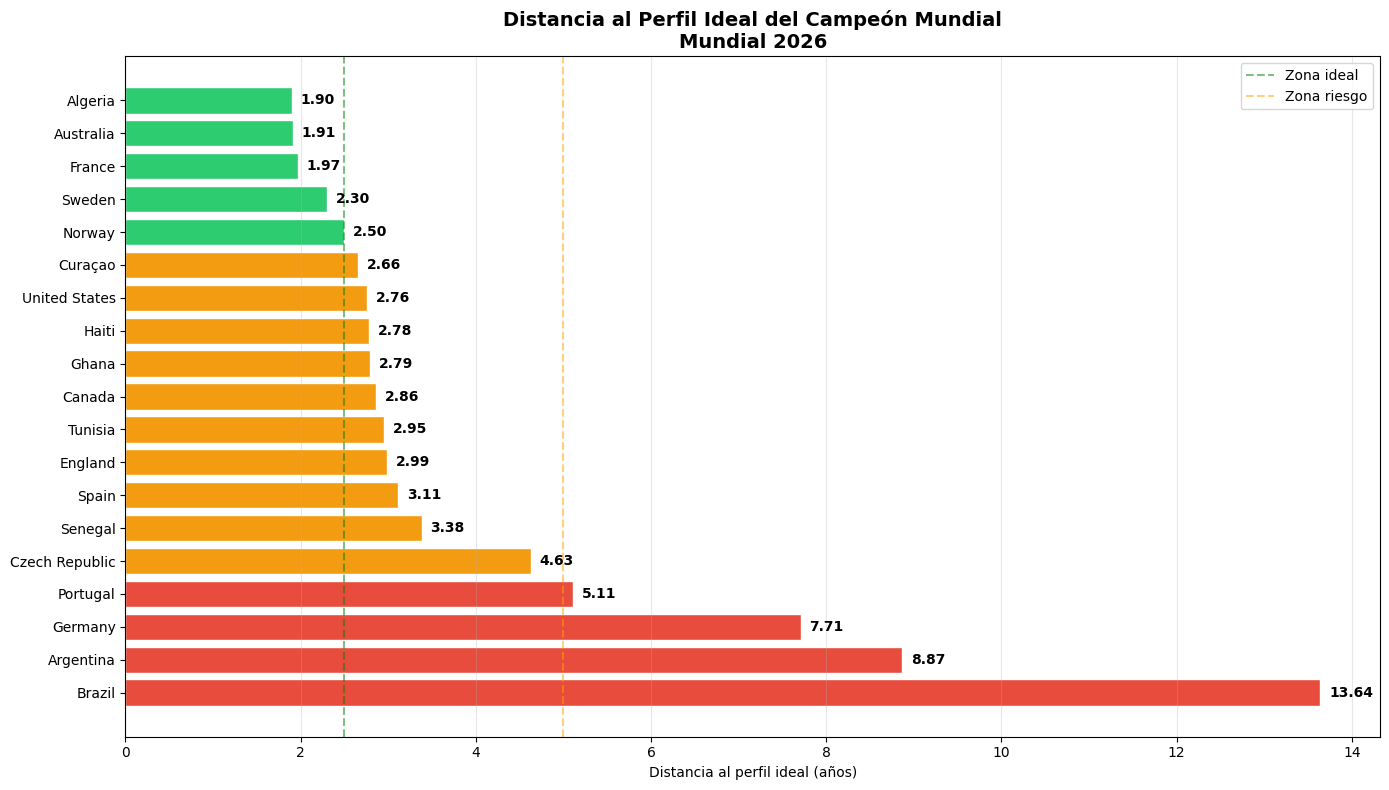

In [29]:
# Top 15 y favoritos juntos
top15 = df_distancias.head(15)['Seleccion'].tolist()
favoritos_lista = ['Argentina', 'Brazil', 'Spain', 'Germany', 'Portugal', 'England', 'France']
selecciones_grafica = list(dict.fromkeys(top15 + favoritos_lista))

df_grafica = df_distancias[df_distancias['Seleccion'].isin(selecciones_grafica)].head(20)

fig, ax = plt.subplots(figsize=(14, 8))

colores = ['#2ecc71' if d <= 2.5 else '#f39c12' if d <= 5 else '#e74c3c' 
           for d in df_grafica['Distancia_Total']]

bars = ax.barh(df_grafica['Seleccion'], df_grafica['Distancia_Total'], 
               color=colores, edgecolor='white')

# Etiquetas
for bar, val in zip(bars, df_grafica['Distancia_Total']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=2.5, color='green', linestyle='--', alpha=0.5, label='Zona ideal')
ax.axvline(x=5.0, color='orange', linestyle='--', alpha=0.5, label='Zona riesgo')

ax.set_title('Distancia al Perfil Ideal del Campeón Mundial\nMundial 2026', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Distancia al perfil ideal (años)')
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [33]:
# Recreamos el IPR con valores exactos
datos_revelaciones = {
    "Seleccion": ["Ecuador", "United States", "Japan", "Canada", 
                  "Czech Republic", "Turkey", "Morocco"],
    "IPR_Total": [94.7, 93.3, 92.8, 90.8, 90.0, 74.3, 73.8]
}

df_revelaciones = pd.DataFrame(datos_revelaciones)

# Ahora sí corremos el score final
dist_max = df_distancias['Distancia_Total'].max()
df_distancias['Score_Edad'] = (100 - (df_distancias['Distancia_Total'] / dist_max * 100)).round(2)

ipr_promedio = df_revelaciones['IPR_Total'].mean().round(2)
df_distancias['Score_IPR'] = ipr_promedio

for _, fila in df_revelaciones.iterrows():
    df_distancias.loc[df_distancias['Seleccion'] == fila['Seleccion'], 'Score_IPR'] = fila['IPR_Total']

df_distancias['Score_Final'] = (
    df_distancias['Score_Edad'] * 0.60 + 
    df_distancias['Score_IPR'] * 0.40
).round(2)

df_final = df_distancias.sort_values('Score_Final', ascending=False)

print("🏆 Top 10 — Score Final Mundial 2026:")
print(df_final[['Seleccion', 'Score_Edad', 'Score_IPR', 'Score_Final']].head(10))

🏆 Top 10 — Score Final Mundial 2026:
        Seleccion  Score_Edad  Score_IPR  Score_Final
0         Algeria       86.07       87.1        86.48
2       Australia       86.00       87.1        86.44
17         France       85.56       87.1        86.18
45  United States       79.77       93.3        85.18
41         Sweden       83.14       87.1        84.72
30         Norway       81.67       87.1        83.84
7          Canada       79.03       90.8        83.74
11        Curaçao       80.50       87.1        83.14
20          Haiti       79.62       87.1        82.61
19          Ghana       79.55       87.1        82.57


In [34]:
favoritos = ['Argentina', 'Brazil', 'Spain', 'Germany', 
             'Portugal', 'England', 'France']

print("📊 Score Final de los favoritos:")
print(df_final[df_final['Seleccion'].isin(favoritos)]
      [['Seleccion', 'Score_Edad', 'Score_IPR', 'Score_Final']])

📊 Score Final de los favoritos:
    Seleccion  Score_Edad  Score_IPR  Score_Final
17     France       85.56       87.1        86.18
16    England       78.08       87.1        81.69
40      Spain       77.20       87.1        81.16
33   Portugal       62.54       87.1        72.36
18    Germany       43.48       87.1        60.93
1   Argentina       34.97       87.1        55.82
6      Brazil        0.00       87.1        34.84


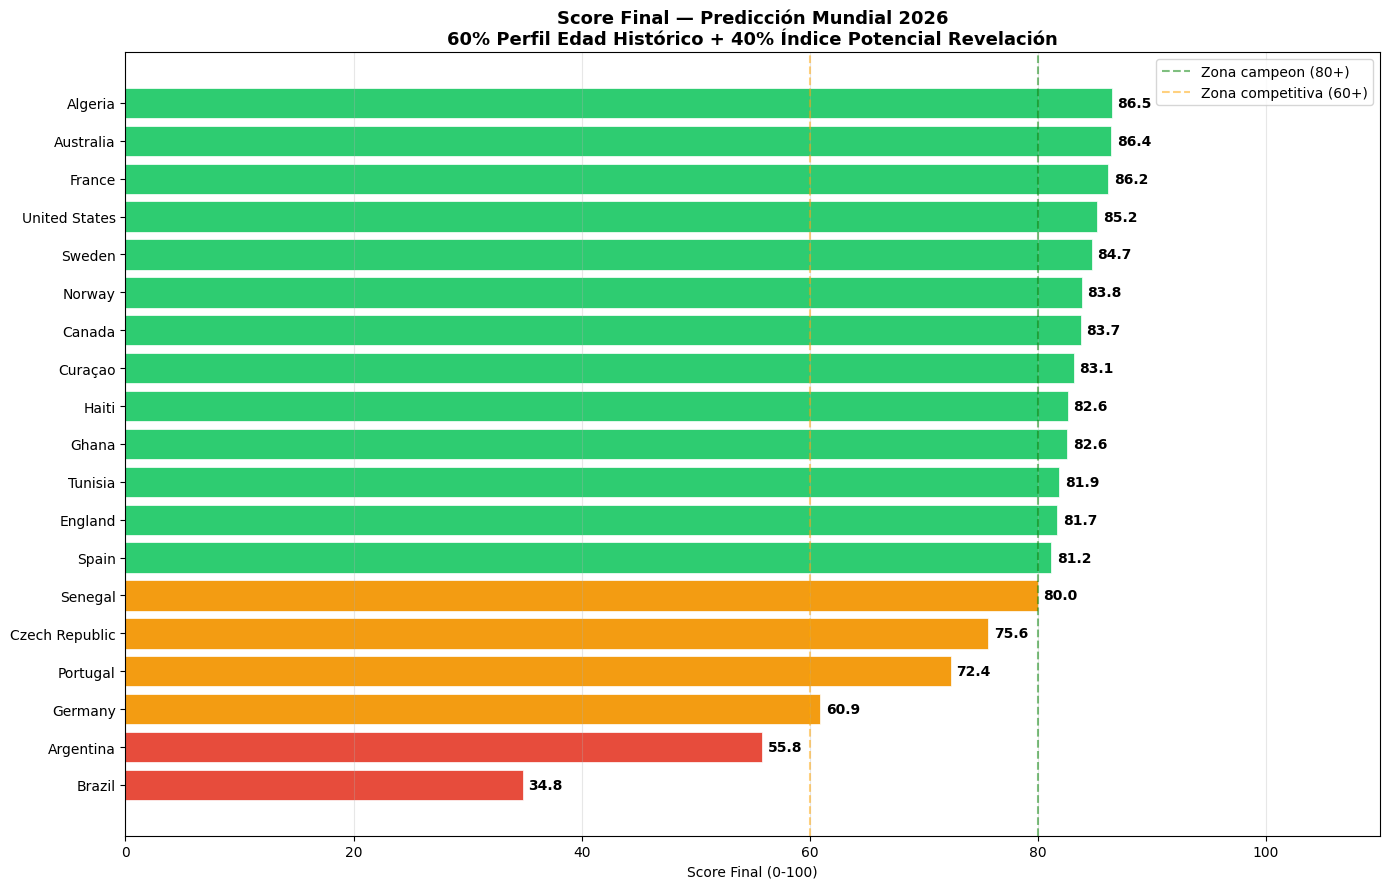

In [35]:
# Top 15 + favoritos
top15 = df_final.head(15)['Seleccion'].tolist()
favoritos_lista = ['Argentina', 'Brazil', 'Spain', 
                   'Germany', 'Portugal', 'England', 'France']
selecciones_grafica = list(dict.fromkeys(top15 + favoritos_lista))

df_grafica = df_final[df_final['Seleccion'].isin(selecciones_grafica)].head(20)

fig, ax = plt.subplots(figsize=(14, 9))

colores = ['#2ecc71' if s >= 80 else '#f39c12' if s >= 60 else '#e74c3c' 
           for s in df_grafica['Score_Final']]

bars = ax.barh(df_grafica['Seleccion'], df_grafica['Score_Final'],
               color=colores, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, df_grafica['Score_Final']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

ax.axvline(x=80, color='green', linestyle='--', alpha=0.5, label='Zona campeon (80+)')
ax.axvline(x=60, color='orange', linestyle='--', alpha=0.5, label='Zona competitiva (60+)')

ax.set_title('Score Final — Predicción Mundial 2026\n60% Perfil Edad Histórico + 40% Índice Potencial Revelación', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Score Final (0-100)')
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, 110)

plt.tight_layout()
plt.show()